### Bias analysis with finite sampling, autosomes
We don't have the luxury to sample every mosquito in a population - thus we can only infer the underlying population through samples. Sampling comes with sampling error, unavoidably. Statiscians like me have been inventing estimators to give the best guess of the parameter of interest. Just like humans, some estimators are "smarter" than the others... 

For example, the Nei's estimator for FST (Eqn 8, Bhatia et al., 2013) is a raw, primitive one as it doesn't consider sample sizes. It is almost certainly biased when it is computed from observed allele frequencies. 

For completeness, Nei's FST looks like this: 
$$FST_{Nei}=\frac{(p_1-p_2)^2}{\overline{p}(1-\overline{p})}$$

Hudson's FST (Eqn 10, Bhatia et al.), has additional terms to incorporate sample sizes: 
$$FST_{Hudson}=\frac{(p_1-p2)^2-p1(1-p1)/(n_1-1)-p2(1-p2)/(n_2-1}{p1(1-p2)+p2(1-p1)}$$

So what are $n_1$ and $n_2$? I think they are *haploid* sample size, i.e. the number of copies of alleles sampled. There is also Weir and Cockerham, etc. 

The idea is to investigate the bias and variance of the two estimators. Look for the definitions for bias, variance, and MSE - the three metrics to evaluate estimators. 

The procedure is as follows: 
1) Simulate one set of the populations, get the true allele frequencies, get the raw (Nei) FST. And this is our true FST. 

2) From this set of true population, choose a sample size, introduce binomial sampling, get the observed allele frequencies, estimate (or re-estimate) FST using Nei's and Hudson's methods. 

3) Repeat 500 times (say) to get 500 Nei's and 500 Hudson's FSTs. Find the sample mean and variance of these 500 numbers. 

4) Further repeat for other sample sizes. 

5) Make plots of bias and variance as a function of sample sizes. 

The code is given below. 

In [1]:
# LOAD PACKAGES
require(doParallel)

Loading required package: doParallel
Loading required package: foreach
Loading required package: iterators
Loading required package: parallel


In [2]:
sim_multi_autosomes<-function(Nm=c(100, 100), Nf=c(100, 100), 
            Mm=matrix(c(0.95, 0.05, 0.05, 0.95), nc=2), Mf=matrix(c(0.95, 0.05, 0.05, 0.95), nc=2), 
            L=500, t=10)
{
    # INITIALISATION
    # EMPTY MATRICES. pop1m = ALLELE FREQ OF MALES IN POP1. COLUMNS = TIME. ROWS = LOCI
    pop1m<-matrix(NA, nr=L, nc=t+1)
    pop1f<-matrix(NA, nr=L, nc=t+1)
    pop2m<-matrix(NA, nr=L, nc=t+1)
    pop2f<-matrix(NA, nr=L, nc=t+1)
    # INITIAL FREQ, ALL AROUND 0.5?
    pop1m[,1]<-runif(L, 0.4, 0.6)
    pop1f[,1]<-pop1m[,1]
    pop2m[,1]<-pop1m[,1]
    pop2f[,1]<-pop1m[,1]
    # PROPAGATION
    for (i in 1:t)
    {
        # NEW GAMETE POOL FREQ FOR THE DIFFERENT COMPARTMENTS, AFTER MIGRATION
        gametem<-Mm%*%rbind(pop1m[,i], pop2m[,i])
        gametef<-Mf%*%rbind(pop1f[,i], pop2f[,i])
        # SAMPLING OFFSPRING. FROM MALE AND FEMALE PARENTS
        pop1m[,i+1]<-(rbinom(L, size=Nm[1], prob=gametem[1,])+rbinom(L, size=Nm[1], prob=gametef[1,]))/(2*Nm[1])
        pop1f[,i+1]<-(rbinom(L, size=Nf[1], prob=gametem[1,])+rbinom(L, size=Nf[1], prob=gametef[1,]))/(2*Nf[1])
        pop2m[,i+1]<-(rbinom(L, size=Nm[2], prob=gametem[2,])+rbinom(L, size=Nm[2], prob=gametef[2,]))/(2*Nm[2])
        pop2f[,i+1]<-(rbinom(L, size=Nf[2], prob=gametem[2,])+rbinom(L, size=Nf[2], prob=gametef[2,]))/(2*Nf[2])
    }
    # RETURN ALL THE ALLELE FREQ
    return(list(pop1m=pop1m, pop1f=pop1f, pop2m=pop2m, pop2f=pop2f))
}
#
cal_nei_fst<-function(p1, p2)
{
    p<-(p1+p2)/2
    return(mean((p1-p2)^2/(2*p*(1-p)), na.rm=T))
}
#
cal_hudson_fst<-function(p1, p2, n1, n2)
{
    temp1<-(p1-p2)^2-p1*(1-p1)/(n1-1)-p2*(1-p2)/(n2-1)
    temp2<-p1*(1-p2)+p2*(1-p1)
    return(mean(temp1/temp2, na.rm=T))
}

### 1. Sim the true population, get the true allele frequency, true (Nei = raw) FST

In [3]:
# THE TRUE PARAMETERS
L<-500
Nm<-c(1000, 1000)
Nf<-c(1000, 1000)
m<-0.01
Mm<-matrix(c(1-m, m, m, 1-m), nc=2)
Mf<-matrix(c(1-m, m, m, 1-m), nc=2)
t<-60
# SIM THE POPULATION
dat<-sim_multi_autosomes(Nm=Nm, Nf=Nf, Mm=Mm, Mf=Mf, L=L, t=t)
# p1 AND p2 FROM THE FINAL GENERATION
p1m<-dat$pop1m[,t+1]
p1f<-dat$pop1f[,t+1]
p2m<-dat$pop2m[,t+1]
p2f<-dat$pop2f[,t+1]
p1<-(p1m+p1f)/2
p2<-(p2m+p2f)/2
# POPULATION TRUE FST
true_FST<-cal_nei_fst(p1, p2)
true_FST

[1] 0.005443469

### 2. From this true population, add sampling, get observed allele frequency, calculate Nei and Hudson's FST
The <code>n</code> below is defined as the sample size per sex per population, meaning we are sampling <code>2n</code> individuals per population, and <code>4n</code> copies of alleles per population. As a result, <code>4n</code> is used in the Hudson's formula. 

In [4]:
# AN ARRAY OF SAMPLE SIZES (SAMPLE SIZE PER SEX PER POPULATION)
n<-seq(10, 150, 10)
length(n)
times<-500
# EMPTY VECTORS FOR AVERAGE FST
nei_FST<-rep(NA, length(n))
hudson_FST<-rep(NA, length(n))
# LET'S LOOK AT THE VARIANCE AS WELL
var_nei_FST<-rep(NA, length(n))
var_hudson_FST<-rep(NA, length(n))
#
cl<-makeCluster(6)
registerDoParallel(cl)
#
for (i in 1:length(n))
{
    temp<-foreach(j=1:times, .combine='rbind') %dopar%
    {
        # GET THE OBSERVED FREQ (ADD BINOMIAL SAMPLING)
        x1<-(rbinom(L, size=2*n[i], prob=p1m)+rbinom(L, size=2*n[i], prob=p1f))/(4*n[i])
        x2<-(rbinom(L, size=2*n[i], prob=p2m)+rbinom(L, size=2*n[i], prob=p2f))/(4*n[i])
        # THE TWO FST ESTIMATORS
        return(c(cal_nei_fst(x1, x2), cal_hudson_fst(x1, x2, 4*n[i], 4*n[i])))
    }
    # FOR EACH n GET THE AVERAGE FROM 500 SIMS
    nei_FST[i]<-mean(temp[,1], na.rm=T)
    hudson_FST[i]<-mean(temp[,2], na.rm=T)
    # GET THE VARIANCE
    var_nei_FST[i]<-var(temp[,1], na.rm=T)
    var_hudson_FST[i]<-var(temp[,2], na.rm=T)
}
stopCluster(cl)

[1] 15

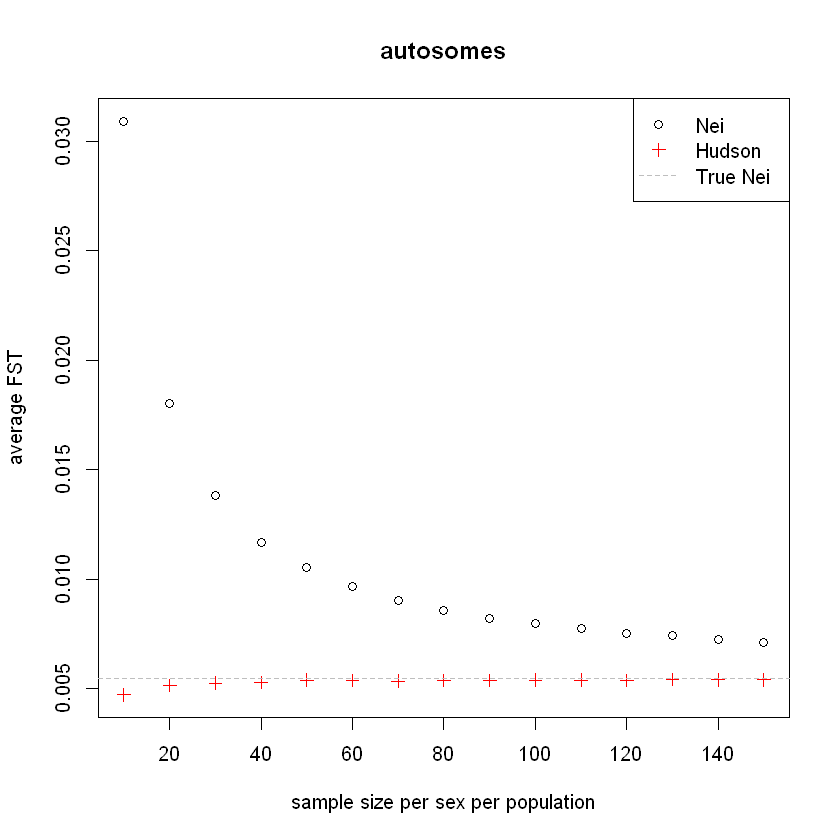

In [5]:
plot(n, nei_FST, ylim=c(min(nei_FST, hudson_FST), max(nei_FST, hudson_FST)), 
    ylab='average FST', xlab='sampled individuals per sex per population', main='autosomes')
points(n, hudson_FST, col='red', pch=3)
abline(h=true_FST, col='grey', lty=2)
legend('topright', legend=c('Nei', 'Hudson', 'True Nei'), col=c(1, 2, 'grey'), lty=c(NA, NA, 2), pch=c(1, 3, NA))

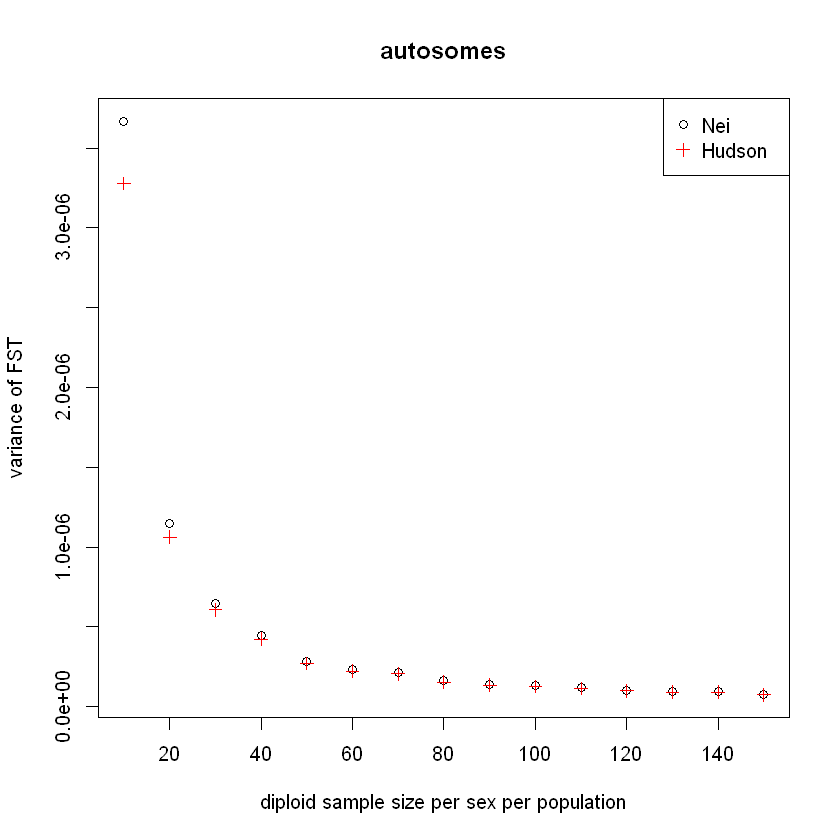

In [6]:
plot(n, var_nei_FST, ylim=c(min(var_nei_FST, var_hudson_FST), max(var_nei_FST, var_hudson_FST)), 
    ylab='variance of FST', xlab='sampled individuals size per sex per population', main='autosomes')
points(n, var_hudson_FST, col='red', pch=3)
legend('topright', legend=c('Nei', 'Hudson'), col=c(1, 2), pch=c(1, 3))